In [3]:
# import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# import the dataset

data = pd.read_csv(r'airlines_flights_data.csv')

In [9]:
data

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [10]:
# let's remove the index column
data.drop(columns='index', inplace=True)

In [11]:
# let's check the info of dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [12]:
# let's check if there are any null values
data.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

#### Business Problem 1: What are the airlines in the dataset, accompanied by their frequencies?

In [13]:
data.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [14]:
# checking which airlines are in the dataset
data['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

In [15]:
# let's check the airlines with their frequencies
data['airline'].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

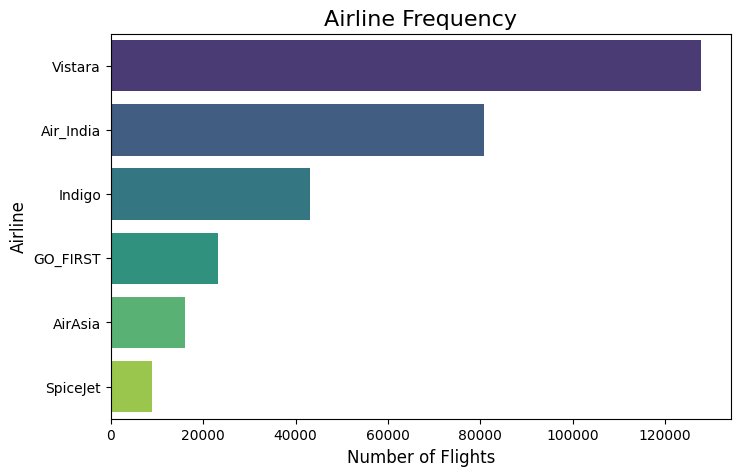

In [24]:
# showing all the airlines with their number of flights in horizontal bar graph
airline_counts = data['airline'].value_counts()
palette = sns.color_palette("viridis", len(airline_counts))
plt.figure(figsize=(8, 5))
sns.barplot(
    x=airline_counts.values,
    y=airline_counts.index,
    hue=airline_counts.index,
    palette=palette
)
plt.title("Airline Frequency", fontsize=16)
plt.xlabel("Number of Flights", fontsize=12)
plt.ylabel("Airlines", fontsize=12)
plt.show()

#### Business problem 2: analyze the distribution of flight depature time and arrival time

In [25]:
data.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [30]:
# checking the departure time of filghts
data['departure_time'].value_counts()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

In [33]:
# checking the arrival time of flights
data['arrival_time'].value_counts()

arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

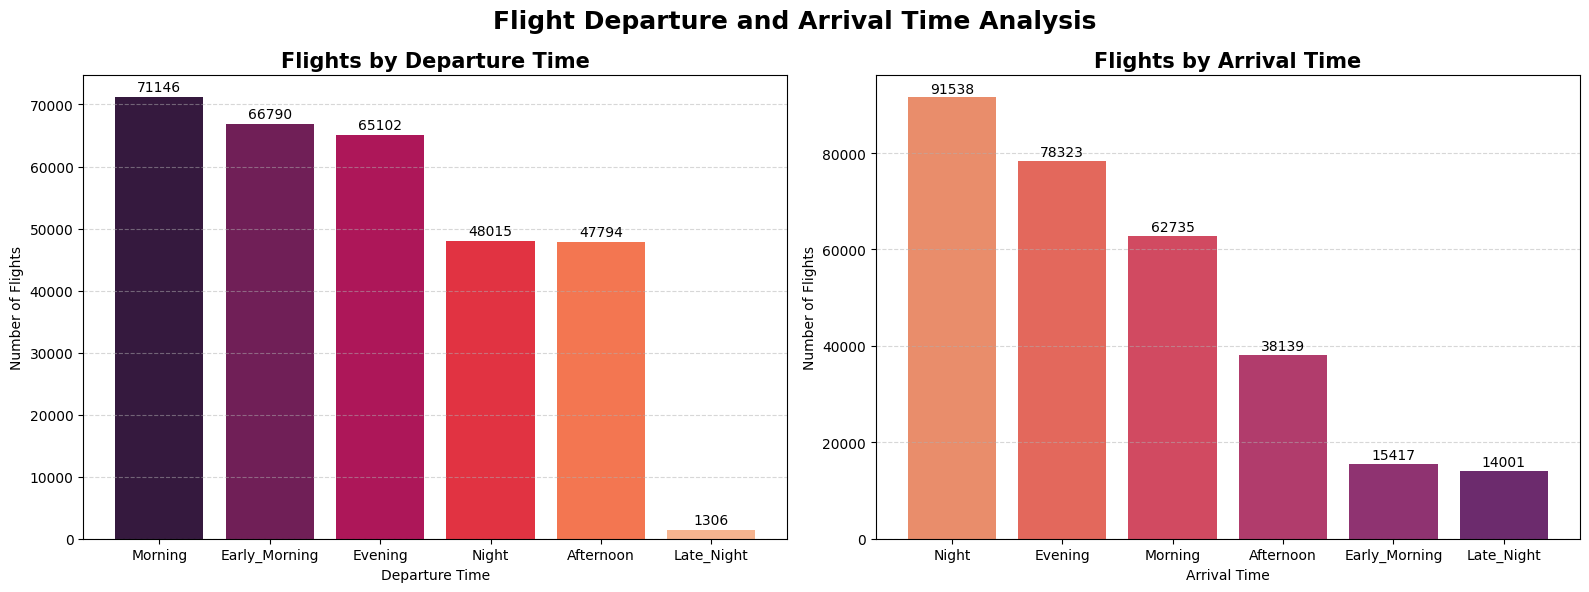

In [43]:
# showing the bar graph for flights by arrival and departure time
# Count values
departure_counts = data['departure_time'].value_counts()
arrival_counts = data['arrival_time'].value_counts()

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color palettes
colors1 = sns.color_palette("rocket", len(departure_counts))
colors2 = sns.color_palette("flare", len(arrival_counts))

# ---------------- Departure Chart ---------------- #
bars1 = axes[0].bar(
    departure_counts.index,
    departure_counts.values,
    color=colors1
)

axes[0].set_title('Flights by Departure Time', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Departure Time')
axes[0].set_ylabel('Number of Flights')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Add values on top of bars (Departure)
for bar in bars1:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        height + 1000,
        f'{int(height)}',
        ha='center',
        fontsize=10
    )

# ---------------- Arrival Chart ---------------- #
bars2 = axes[1].bar(
    arrival_counts.index,
    arrival_counts.values,
    color=colors2
)

axes[1].set_title('Flights by Arrival Time', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Arrival Time')
axes[1].set_ylabel('Number of Flights')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Add values on top of bars (Arrival)
for bar in bars2:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height + 1000,
        f'{int(height)}',
        ha='center',
        fontsize=10
    )

# Main title
fig.suptitle(
    'Flight Departure and Arrival Time Analysis',
    fontsize=18,
    fontweight='bold'
)

# Layout adjustment
plt.tight_layout()
plt.show()

#### Business problem 3: analyze the flights distribution by source city & destination city

In [44]:
data.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [45]:
# check the source city of the flights
data['source_city'].value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

In [47]:
# check the destination city of the flights
data['destination_city'].value_counts()

destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64

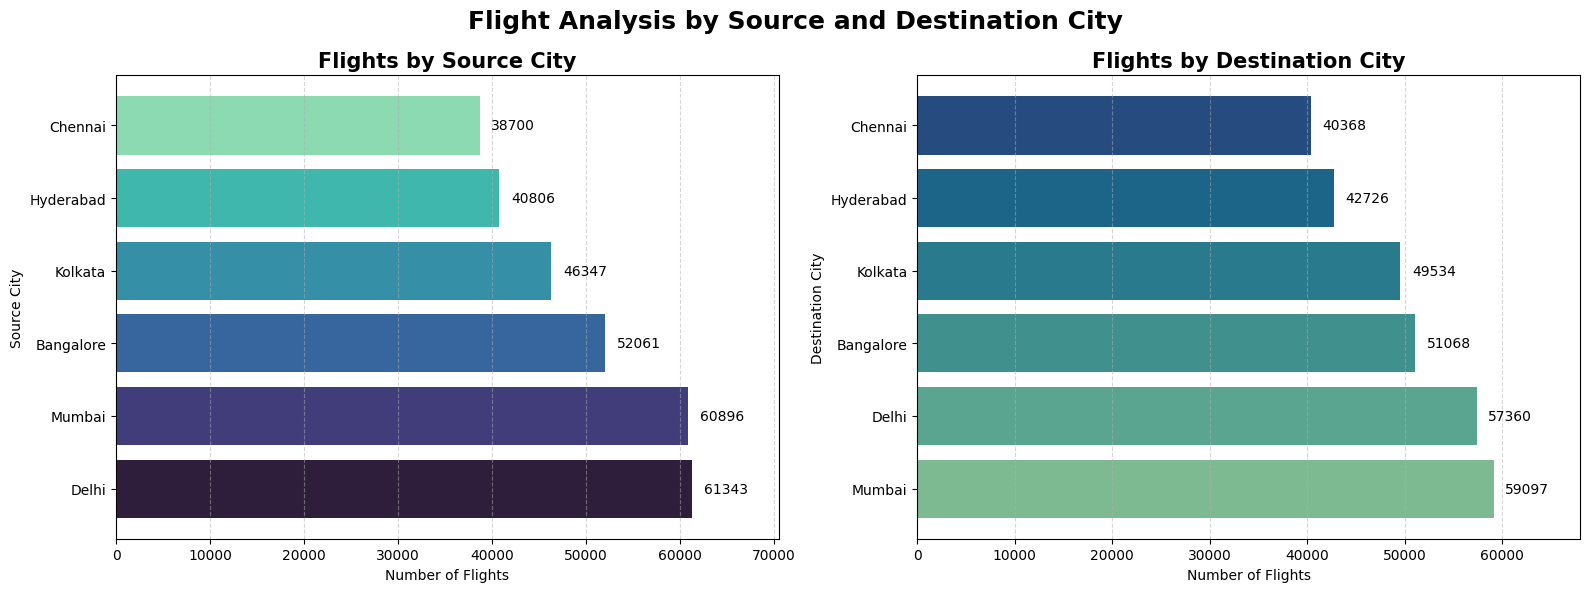

In [55]:
# showing the horizontal bar graph of the flights by source and destination city
# Count values
source_counts = data['source_city'].value_counts()
destination_counts = data['destination_city'].value_counts()

# Create figure with 2 subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color palettes
colors1 = sns.color_palette("mako", len(source_counts))
colors2 = sns.color_palette("crest", len(destination_counts))

# ---------------- Source city Horizontal Bar ---------------- #
bars1 = axes[0].barh(
    source_counts.index,
    source_counts.values,
    color=colors1
)

axes[0].set_title('Flights by Source City', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Number of Flights')
axes[0].set_ylabel('Source City')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# Set x-limit padding
axes[0].set_xlim(0, source_counts.max() * 1.15)

# Add values on bars (source city)
for bar in bars1:
    width = bar.get_width()
    axes[0].text(
        width + source_counts.max()*0.02,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        fontsize=10
    )

# ---------------- destination city Horizontal Bar ---------------- #
bars2 = axes[1].barh(
    destination_counts.index,
    destination_counts.values,
    color=colors2
)

axes[1].set_title('Flights by Destination City', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Number of Flights')
axes[1].set_ylabel('Destination City')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)


# Set x-limit padding
axes[1].set_xlim(0, destination_counts.max() * 1.15)

# Add values on bars (destination city)
for bar in bars2:
    width = bar.get_width()
    axes[1].text(
        width + destination_counts.max()*0.02,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        fontsize=10
    )

# Main title
fig.suptitle(
    'Flight Analysis by Source and Destination City',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

#### Business problem 4: Analyze the flight price for each airline

In [56]:
data.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [59]:
# grouping the airlines and checking their mean price
data.groupby('airline')['price'].mean()

airline
AirAsia       4091.072742
Air_India    23507.019112
GO_FIRST      5652.007595
Indigo        5324.216303
SpiceJet      6179.278881
Vistara      30396.536302
Name: price, dtype: float64

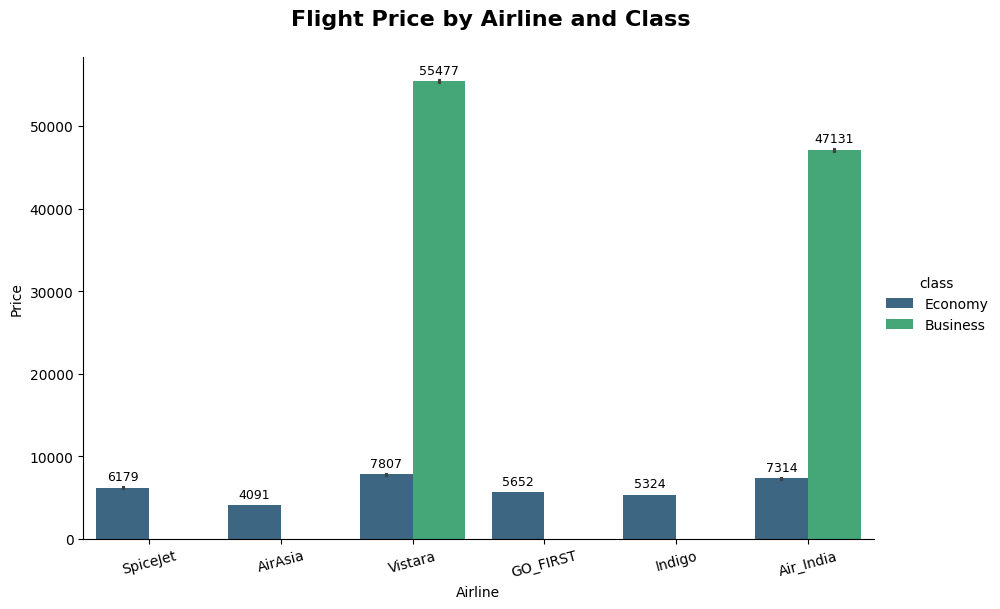

In [18]:
# Create catplot
g = sns.catplot(
    data=data,
    x='airline',
    y='price',
    kind='bar',
    hue='class',
    palette='viridis',
    height=6,
    aspect=1.5
)

# Title and labels
g.set_axis_labels("Airline", "Price")
g.fig.suptitle("Flight Price by Airline and Class", fontsize=16, fontweight='bold')

# Adjust title spacing
plt.subplots_adjust(top=0.9)

# Rotate x-axis labels
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=15)

# Add values on bars
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9)

plt.show()

#### Business problem 5: Does the ticket price are change based on the departure time and arrival time?

In [7]:
data.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [8]:
# checking the mean ticket price based on the departure time
data.groupby('departure_time')['price'].mean()

departure_time
Afternoon        18179.203331
Early_Morning    20370.676718
Evening          21232.361894
Late_Night        9295.299387
Morning          21630.760254
Night            23062.146808
Name: price, dtype: float64

In [9]:
# checking the mean ticket price based on the arrival time
data.groupby('arrival_time')['price'].mean()

arrival_time
Afternoon        18494.598993
Early_Morning    14993.139521
Evening          23044.371615
Late_Night       11284.906078
Morning          22231.076098
Night            21586.758341
Name: price, dtype: float64

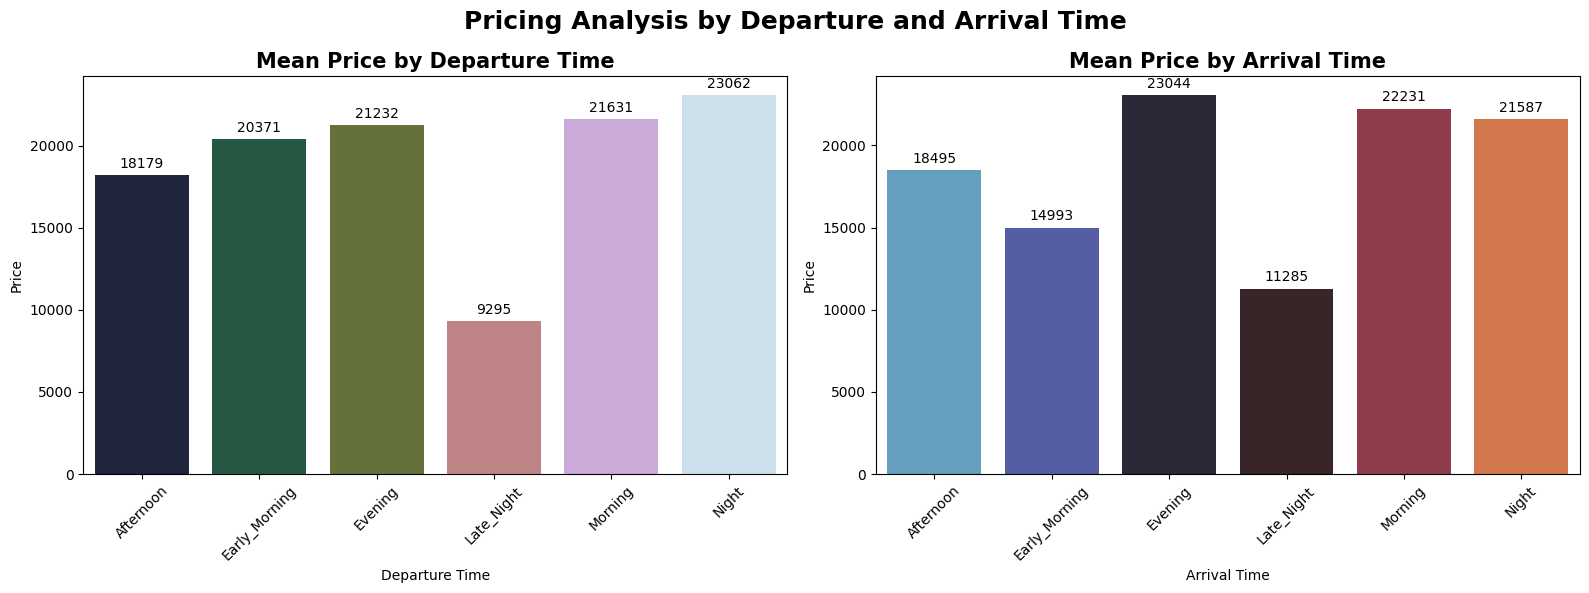

In [22]:
# create visual for our calculation
# Mean price by departure time
dep_mean = data.groupby('departure_time')['price'].mean().reset_index()

# Mean price by arrival time
arr_mean = data.groupby('arrival_time')['price'].mean().reset_index()

# Create subplot layout
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Departure Time Plot
sns.barplot(
    x='departure_time',
    y='price',
    data=dep_mean,
    palette='cubehelix',
    hue='departure_time',
    ax=axes[0]
)

axes[0].set_title('Mean Price by Departure Time', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Departure Time')
axes[0].set_ylabel('Price')
axes[0].tick_params(axis='x', rotation=45)

# Add values on bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f', padding=3)

# Arrival Time Plot
sns.barplot(
    x='arrival_time',
    y='price',
    data=arr_mean,
    palette='icefire',
    hue='arrival_time',
    ax=axes[1]
)

axes[1].set_title('Mean Price by Arrival Time', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Arrival Time')
axes[1].set_ylabel('Price')
axes[1].tick_params(axis='x', rotation=45)

# Add values on bars
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f', padding=3)

# Main title
fig.suptitle(
    'Pricing Analysis by Departure and Arrival Time',
    fontsize=18,
    fontweight='bold'
)

# Adjust spacing
plt.tight_layout()

# Show plots
plt.show()

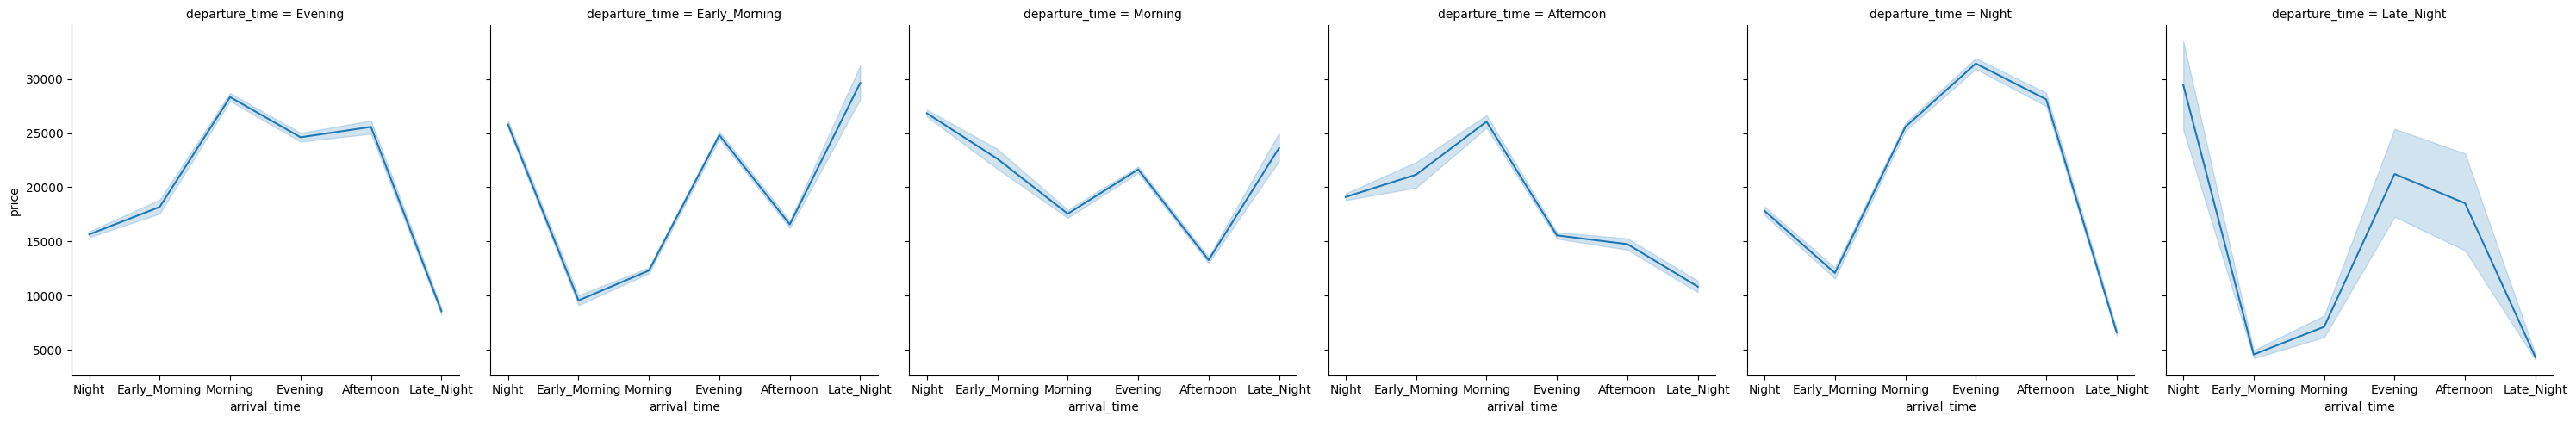

In [7]:
# let's create relational plot for better understanding
sns.relplot(x='arrival_time', y='price', data=data, col='departure_time', kind='line')
plt.show()

#### Business problem 6: How the price changes with change in source and destination city

In [6]:
data.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [8]:
# checking the mean ticket price for each source city
data.groupby('source_city')['price'].mean()

source_city
Bangalore    21469.460575
Chennai      21995.339871
Delhi        18951.326639
Hyderabad    20155.623879
Kolkata      21746.235679
Mumbai       21483.818839
Name: price, dtype: float64

In [9]:
# checking the mean ticket price for each destination city
data.groupby('destination_city')['price'].mean()

destination_city
Bangalore    21593.955784
Chennai      21953.323969
Delhi        18436.767870
Hyderabad    20427.661284
Kolkata      21959.557556
Mumbai       21372.529469
Name: price, dtype: float64

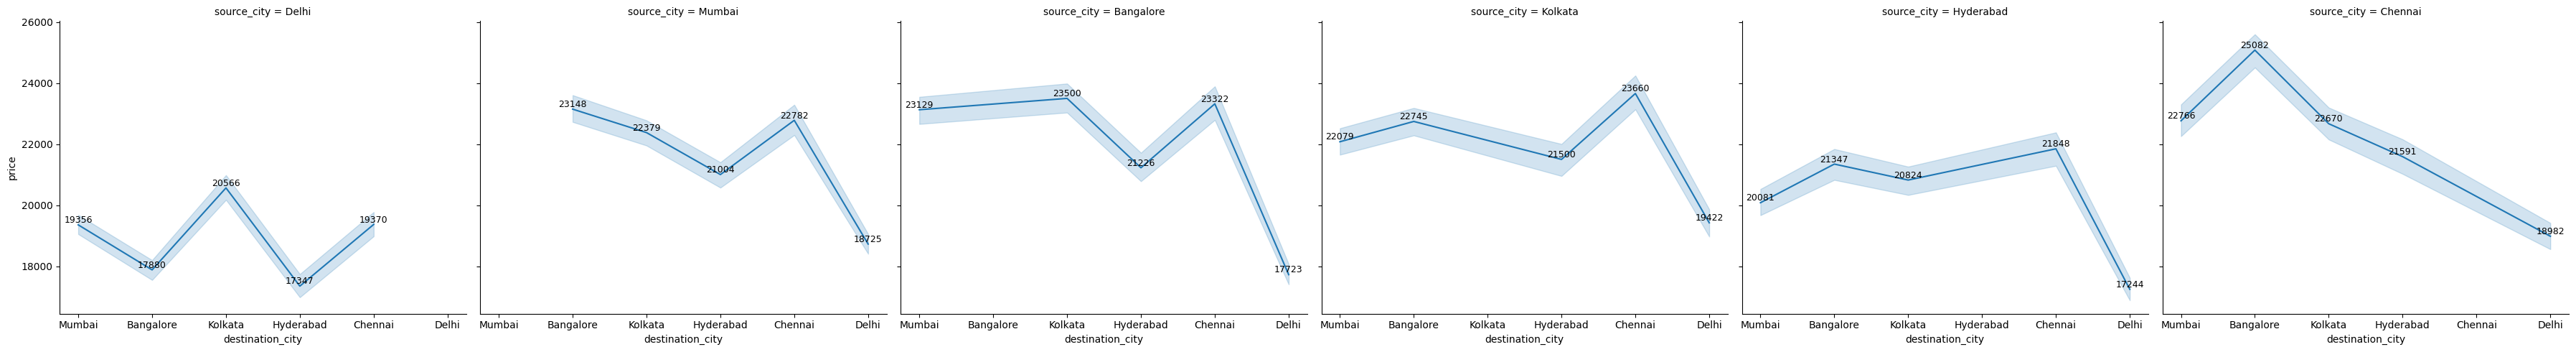

In [15]:
# Create relational line plot
g = sns.relplot(x='destination_city', y='price', data=data, col='source_city', kind='line', markers=True, height=5, aspect=1.2)
# Add value labels on each point
for ax in g.axes.flat:
    
    # Get line data
    for line in ax.lines:
        x_data = line.get_xdata()
        y_data = line.get_ydata()

        # Add labels
        for x, y in zip(x_data, y_data):
            ax.text(
                x,
                y,
                f'{y:.0f}',
                ha='center',
                va='bottom',
                fontsize=9
            )
plt.show()

#### Business problem 7: How is the price affected when tickets are bought in just 1 or 2 days before departure?

In [13]:
data.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [16]:
data['days_left'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [17]:
# check mean ticket price for different days
data.groupby('days_left')['price'].mean()

days_left
1     21591.867151
2     30211.299801
3     28976.083569
4     25730.905653
5     26679.773368
6     24856.493902
7     25588.367351
8     24895.883995
9     25726.246072
10    25572.819134
11    22990.656070
12    22505.803322
13    22498.885384
14    22678.002363
15    21952.540852
16    20503.546237
17    20386.353949
18    19987.445168
19    19507.677375
20    19699.983390
21    19430.494058
22    19590.667385
23    19840.913451
24    19803.908896
25    19571.641791
26    19238.290278
27    19950.866195
28    19534.986047
29    19744.653119
30    19567.580834
31    19392.706612
32    19258.135308
33    19306.271739
34    19562.008266
35    19255.652996
36    19517.688444
37    19506.306516
38    19734.912316
39    19262.095556
40    19144.972439
41    19347.440460
42    19154.261659
43    19340.528894
44    19049.080174
45    19199.876307
46    19305.351623
47    18553.272038
48    18998.126851
49    18992.971888
Name: price, dtype: float64

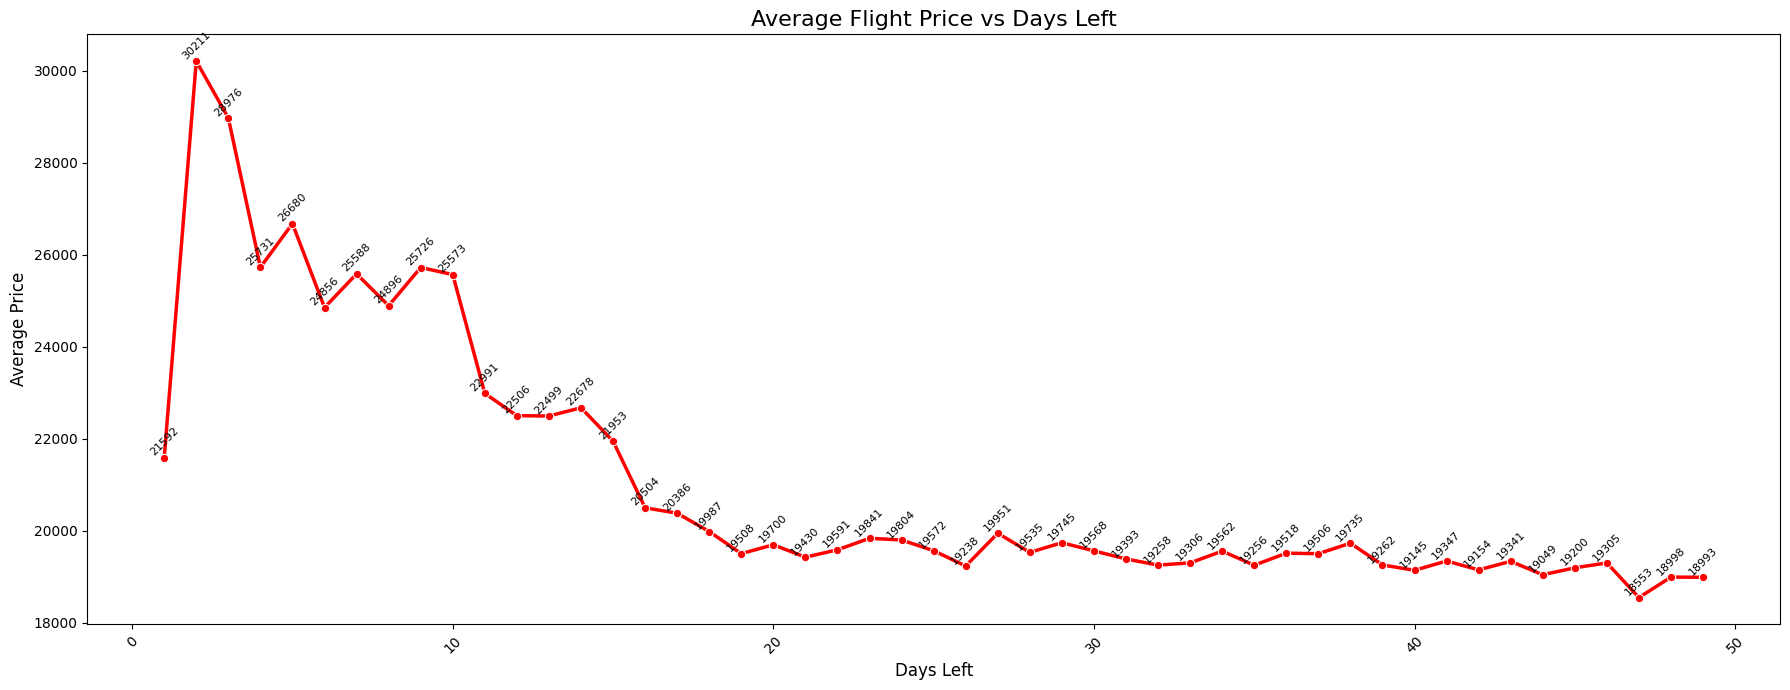

In [27]:
# Create figure
plt.figure(figsize=(18, 7))

df = data.groupby('days_left')['price'].mean().reset_index()

# Line plot
sns.lineplot(
    x='days_left',
    y='price',
    data=df,
    marker='o',
    linewidth=2.5,
    color='red'
)

# Add value labels
for x, y in zip(df['days_left'], df['price']):
    plt.text(
        x,
        y,
        f'{y:.0f}',
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=45
    )

# Titles and labels
plt.title('Average Flight Price vs Days Left', fontsize=16)
plt.xlabel('Days Left', fontsize=12)
plt.ylabel('Average Price', fontsize=12)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Tight layout
plt.tight_layout()

# Show plot
plt.show()

#### Business problem 8: How does the ticket price vary between economy and business class?

In [28]:
data.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [29]:
data['class'].unique()

array(['Economy', 'Business'], dtype=object)

In [35]:
# create variable for values which have economy class
x = data[data['class'] == 'Economy']
x.price.mean()

np.float64(6572.342383362527)

In [37]:
# create variable for values which have business class
y = data[data['class'] == 'Business']
y.price.mean()

np.float64(52540.08112357868)

In [40]:
variation = data.groupby('class')['price'].mean()
print('The average price difference between business class and economy class:',
     variation['Business'] - variation["Economy"])

The average price difference between business class and economy class: 45967.738740216155


#### Business problem 9: what will be the average price of vistara airline for a flight from delhi to hyderabad in business class?

In [56]:
price = data[(data['airline'] == 'Vistara') &
(data['source_city'] == 'Delhi') &
(data['destination_city'] == 'Hyderabad') &
(data['class'] == 'Business')]

print('The Average price of Vistara airline for flight from Delhi to Hyderabad in Business class is',price['price'].mean())

The Average price of Vistara airline for flight from Delhi to Hyderabad in Business class is 47939.840361445786
